# Test-Driven Data Science

## Introduction

In Lesson 1 you fetched financial data from a web API, saved it as a CSV,
computed returns, and watched volatility cluster. That workflow leaned on
**loose variables and standalone function calls** — perfect for
exploration, but fragile the moment you need to repeat the steps for a new
stock or hand the code to a teammate.

> ❓ How do you turn a one-off exploratory script into a *reusable,
> trustworthy* data layer that the rest of the project can build on
> without re-reading every line?

The answer this lesson teaches is two-fold: **organise the code into
classes**, and **guard every component with tests**. You will package the
data-access logic into an `AlphaVantageAPI` class (for retrieving data)
and a `SQLRepository` class (for persisting it in SQLite), building both
with **test-driven development (TDD)** — writing `assert` statements that
specify correct behaviour *before* (or alongside) the code that satisfies
them.

> 🔄 **One deliberate change from Lesson 1.** From here on the project
> uses **simple percentage returns** (`pct_change() * 100`) instead of log
> returns. A value of `2.0` now reads directly as "a 2% rise," and simple
> returns plug straight into the `arch` GARCH models of Lesson 3. For the
> small daily moves typical of equities the two definitions nearly
> coincide, so every intuition from Lesson 1 still holds.

🎯 **By the end of this notebook you will be able to:**

-   Organise data-access code into an `AlphaVantageAPI` class with a
    `get_daily` method.
-   Create a `SQLRepository` class that can insert and read tables from
    a SQLite database.
-   Apply test-driven development by writing `assert` statements to
    validate class behaviour.
-   Store stock data in a SQLite database and retrieve it for analysis.
-   Compute daily percentage returns and compare the volatility of two
    stocks.

➡️ Watch the short walkthrough, then we build the data layer class by
class, test first.

In [1]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1183285621", h="3298dbabb7", width=700, height=450)  

# 1. Conceptual Foundation

## Project context: what we're trying to build

Across Project 8 you are assembling an **end-to-end volatility system**:
fetch data → store it → model it → deploy it. This lesson owns the **data
layer** — a small Python module called `data` containing two classes:

| Class | Responsibility | Key methods |
|---|---|---|
| `AlphaVantageAPI` | request daily OHLCV prices and return a clean DataFrame | `get_daily` |
| `SQLRepository` | write DataFrames to SQLite and read them back | `insert_table`, `read_table` |

> 🧱 Why split fetching from storage? **Separation of concerns.** Code
> that *gets* data should not also worry about *where it lives*. Each
> class does one job, so each can be tested — and later replaced — in
> isolation. Downstream code (visualisation, modelling, deployment) then
> trusts the data it receives because the tests vouch for it.

➡️ Trust is the operative word, and trust is exactly what tests buy you.

## Test-driven development in data science

Test-driven development (TDD) is a practice where you write a test
*before* the code that makes it pass. The loop is summarised as
**Red → Green → Refactor**:

| Phase | What you do | State of the test |
|---|---|---|
| 🔴 **Red** | write a test for a feature that doesn't exist yet | **fails** |
| 🟢 **Green** | write the *minimum* code to make it pass | **passes** |
| 🔵 **Refactor** | clean up the code, keeping the test green | still **passes** |

> 💡 Why bother in data science? Because data bugs are **silent**. A
> function that returns `None` instead of a DataFrame, or shifts an index
> by one row, won't crash — it will quietly poison every downstream
> number. TDD forces you to state up front *what correct output looks
> like* (type, shape, column names, value ranges) and encode that as
> `assert` statements that fail loudly the instant reality diverges.

### How `assert` works

An `assert` statement evaluates an expression. If it is `True`, execution
continues silently; if `False`, Python raises an `AssertionError`. You can
attach a message to make the failure informative.

In [1]:
# A passing assertion — nothing happens
x = 42
assert x == 42, f"Expected 42, got {x}"

The assertion above passed, so **nothing printed** — that is the expected,
quiet success of a green test. The next cell shows the opposite case (left
commented so the notebook still runs top to bottom): uncomment it to watch
a failing assertion raise an `AssertionError` carrying its message.

In [3]:
# A failing assertion — uncomment to see the error
# y = 10
# assert y > 100, f"Expected y > 100, got {y}"

Adding context with f-strings is essential: in a long notebook a bare
`assert` tells you almost nothing, whereas
`f"Expected shape (100, 5), got {df.shape}"` pinpoints exactly what went
wrong.

> 🔧 Practical tips for writing good assertions
>
> - **Test the type first**, then shape, then values — this catches the
>   most common bug (a `None` where a DataFrame should be) earliest.
> - **Test edge cases:** what happens with `limit=0`, or a ticker that
>   doesn't exist?
> - **Keep each assertion on its own line** so a failure points to
>   exactly one condition.
> - **Use `isinstance()` for type checks** and `df.shape`,
>   `df.columns.tolist()`, `df.dtypes` for structural checks.

➡️ TDD needs something to test. In this lesson that something is a pair of
**classes**, so here is a quick refresher on how classes work.

## Classes and the `__init__` method — a recap

A class is a **blueprint for objects that bundle related data and actions
together**. Without classes you might keep an API key in one variable, a
ticker in another, and scatter functions that must be called in just the
right order with just the right arguments. A class folds all of that into
one self-contained unit.

> 🧱 The vocabulary, in one place
>
> - **class** — the blueprint (no object exists yet).
> - **instance** — a concrete object built from the blueprint.
> - **`__init__`** — the constructor; runs automatically when you create
>   an instance, used to store initial configuration.
> - **`self`** — how an instance refers to itself; `self.x = x` saves a
>   value so other methods can reach it later.
> - **method** — a function defined inside the class that acts on the
>   instance via `self`.

Here is a minimal example that exercises every term above:

In [2]:
class Greeter:
    """Minimal class to illustrate __init__ and a method."""

    def __init__(self, name):
        # Store data inside the object using 'self'
        self.name = name

    def greet(self):
        # Methods can access stored data via 'self'
        return f"Hello, {self.name}!"


g = Greeter("World")
print(g.greet())
print("Attribute 'name':", g.name)

Hello, World!
Attribute 'name': World


Tracing the demo against the vocabulary:

-   **`class Greeter:`** defines the blueprint. No object exists yet.
-   **`g = Greeter("World")`** creates an **instance** — Python
    automatically calls `__init__` and passes `"World"` as `name`.
-   **`self`** is how the object refers to itself; `self.name = name`
    stores the value so other methods can use it.
-   **`g.greet()`** calls a method on the instance — inside `greet`,
    `self.name` is `"World"`.

Crucially, each instance carries its **own** data — create a second one
and it is completely independent of the first:

In [5]:
g2 = Greeter("Python")
print(g2.greet())  # "Hello, Python!" — independent of g

Hello, Python!


> 📌 The two classes you build next follow this exact pattern: `__init__`
> stores configuration (an API key, a database connection) and methods
> perform actions (fetch data, insert a table, read a table). Once an
> instance exists, all its configuration **travels with it** — you never
> repeat the same arguments.

➡️ One class will store its data in a SQLite database, so let's see how
pandas and SQLite talk to each other.

## Working with SQLite and `pandas`

SQLite is a **lightweight, file-based relational database** — a single
file, no server to run. Python's built-in `sqlite3` module opens a
connection and executes SQL; combined with `pandas`, you can move data
between DataFrames and tables in two lines.

> 📦 Why SQLite here? It needs zero setup, ships with Python, and stores
> an entire database in one portable file. For a single-user analytics
> pipeline that has to persist a few stock tables, it is the path of least
> resistance — no MongoDB server, no Postgres instance.

The demo below writes a tiny DataFrame to an **in-memory** database
(`":memory:"`, which vanishes when closed) and reads it back:

In [3]:
import sqlite3
import pandas as pd

# Create an in-memory database for demonstration
demo_conn = sqlite3.connect(":memory:")

# Create a small DataFrame
demo_df = pd.DataFrame(
    {"date": ["2024-01-01", "2024-01-02"], "close": [100.0, 102.5]}
)
demo_df["date"] = pd.to_datetime(demo_df["date"])
demo_df.set_index("date", inplace=True)

# Write to SQLite
demo_df.to_sql("demo_prices", demo_conn, if_exists="replace")

# Read back
result = pd.read_sql(
    "SELECT * FROM demo_prices",
    demo_conn,
    parse_dates=["date"],
    index_col="date",
)
print(result)
print("Type of index:", type(result.index))

demo_conn.close()

            close
date             
2024-01-01  100.0
2024-01-02  102.5
Type of index: <class 'pandas.DatetimeIndex'>


> 📊 What the round-trip shows
>
> - `DataFrame.to_sql()` writes the DataFrame (**including its index**)
>   into a table.
> - `pd.read_sql()` executes a query and returns a DataFrame.
> - Passing `parse_dates` and `index_col` is what restores a proper
>   `DatetimeIndex` on the way back — without them the date would return
>   as plain text. The printed `type(result.index)` confirms it came back
>   as a `DatetimeIndex`.

➡️ Storage handled. The last concept before building is the return
definition this project standardises on.

## Computing percentage returns

A **return** is the relative change in price from one period to the next,
here expressed as a percentage. For a closing-price series $P$, the simple
return on day $t$ is:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}} \times 100
$$

so a value of `2.0` means the price rose 2% from the previous close. In
pandas this is a single call, `pct_change() * 100`:

In [4]:
demo_prices = pd.Series(
    [100.0, 102.0, 99.0, 101.5],
    index=pd.date_range("2024-01-01", periods=4),
    name="close",
)
demo_returns = demo_prices.pct_change() * 100
print(demo_returns)

2024-01-01         NaN
2024-01-02    2.000000
2024-01-03   -2.941176
2024-01-04    2.525253
Freq: D, Name: close, dtype: float64


The first value is always `NaN` — there is no previous price to compare
day 0 against.

> ⚠️ **Sort before you compute.** `pct_change()` compares each row to the
> one *above* it, so the data **must** be in ascending date order. If the
> series is reversed (as raw API payloads often are), every return's sign
> flips. Always `sort_index()` first.

➡️ One last piece of infrastructure: the mock that lets all of this run
without a network.

## The mock: simulating an API without network access

In production you would call the AlphaVantage REST API with a real key.
In this learning environment a helper module called `mock_alpha`
intercepts `requests.get` and returns data from a local JSON file
(`data/alpha_ambujacem_bse_full.json`). This means:

-   You do **not** need an internet connection.
-   The data is **deterministic** — every run produces the same result.
-   You activate the mock with `activate_mock()` and switch it off with
    `deactivate_mock()`.

Your `AlphaVantageAPI` class will call `requests.get` internally; when the
mock is active those calls are intercepted transparently, so **the class
code is identical to what you'd write against the live API** — only the
network layer is simulated.

> 📌 Reference documentation
>
> - [`assert` statement](https://docs.python.org/3/reference/simple_stmts.html#the-assert-statement)
> - [`sqlite3.connect`](https://docs.python.org/3/library/sqlite3.html#sqlite3.connect)
> - [`pandas.DataFrame.to_sql`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_sql.html)
> - [`pandas.read_sql`](https://pandas.pydata.org/docs/reference/api/pandas.read_sql.html)
> - [`pandas.Series.pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html)
> - [`unittest.mock.patch`](https://docs.python.org/3/library/unittest.mock.html#unittest.mock.patch)

➡️ Theory complete. Time to build — and test — the two classes.

# Applied Exercises

## 2. Setup

Import the libraries and helpers you'll use throughout the exercises. It
is good practice to keep all imports in a single cell at the top.

**Code 8.2.2.1**:

In [35]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
from mock_alpha import activate_mock, deactivate_mock

## 3. Building the `AlphaVantageAPI` Class

### Problem

To fetch stock data repeatedly for different tickers you need a reusable
interface. Hard-coding API calls in notebook cells is error-prone and hard
to test. A class encapsulates the API key, the base URL, and the logic for
parsing the JSON response into a clean DataFrame.

### Approach

You will create an `AlphaVantageAPI` class inside a file called `data.py`
(the `data` module). The class needs:

-   An `__init__` method that stores the API key as a private attribute
    `__api_key`. For this lesson any string (e.g., `"demo"`) works because
    the mock intercepts all requests.
-   A `get_daily` method that accepts a `ticker` string and an optional
    `output_size` parameter (default `"full"`), builds the AlphaVantage
    URL, calls `requests.get`, and parses the JSON response into a
    DataFrame with columns `["open", "high", "low", "close", "volume"]`, a
    `DatetimeIndex` named `"date"`, and all-numeric dtypes.

After creating the class you will write `assert` statements (the **Red**
specification) to verify its output.

### Tasks

First, activate the mock so that all `requests.get` calls return local
data.

**Code 8.2.3.1**:

In [3]:
activate_mock()

Create your `AlphaVantageAPI` class in `data.py`, then import it here and
instantiate it. The `print` statement should show that `av` is an instance
of your class.

**Code 8.2.3.2**:

#### from data import AlphaVantageAPI

av = AlphaVantageAPI()
print("av type:", type(av))

Now use the `get_daily` method to fetch data for the ticker
`"AMBUJACEM.BSE"` (Ambuja Cement, listed on the Bombay Stock Exchange).
Assign the result to `df_ambuja`. You should see a DataFrame with five
numeric columns and a date index.

**Code Task 8.2.3.3**:

In [7]:
from data import  AlphaVantageAPI
av = AlphaVantageAPI() 
ticker_ambuja = "AMBUJACEM.BSE"

# Call the get_daily method on your av instance
df_ambuja = av.get_daily(ticker=ticker_ambuja)

print("df_ambuja type:", type(df_ambuja))

print("df_ambuja shape:", df_ambuja.shape)
df_ambuja.head()

df_ambuja type: <class 'pandas.DataFrame'>
df_ambuja shape: (5225, 5)


,open,high,low,close,volume
date,,,,,
2005-01-03,405.0001,409.5001,403.1001,407.6001,1061050.0
2005-01-04,410.0001,429.0001,409.0001,425.8501,2501549.0
2005-01-05,427.0001,439.9001,406.1501,425.9501,3537669.0
2005-01-06,426.0001,431.0001,412.0001,416.0501,3103853.0
2005-01-07,420.0001,428.5001,418.0001,426.3001,2330736.0


Time to write the **test first**. Define six assertions that pin down what
a correct `get_daily` output looks like — type, column count, index type,
index name, column names, and dtypes. Each carries an f-string message so a
failure tells you exactly which expectation broke.

**Code 8.2.3.4**:

In [8]:
# 1. Is df_ambuja a DataFrame?
assert isinstance(
    df_ambuja, pd.DataFrame
), f"Expected pd.DataFrame, got {type(df_ambuja)}"

# 2. Does it have exactly 5 columns?
assert (
    df_ambuja.shape[1] == 5
), f"Expected 5 columns, got {df_ambuja.shape[1]}"

# 3. Does it have a DatetimeIndex?
assert isinstance(
    df_ambuja.index, pd.DatetimeIndex
), f"Expected DatetimeIndex, got {type(df_ambuja.index)}"

# 4. Is the index named 'date'?
assert (
    df_ambuja.index.name == "date"
), f"Expected index name 'date', got '{df_ambuja.index.name}'"

# 5. Are the column names correct?
expected_cols = ["open", "high", "low", "close", "volume"]
assert (
    df_ambuja.columns.tolist() == expected_cols
), f"Expected columns {expected_cols}, got {df_ambuja.columns.tolist()}"

# 6. Are all column dtypes float?
assert all(
    df_ambuja.dtypes == float
), f"Column dtypes: {df_ambuja.dtypes.tolist()}"

print("All AlphaVantageAPI tests passed.")

All AlphaVantageAPI tests passed.


### Checkpoint

> 🧪 This Checkpoint re-runs the full contract for `get_daily` as a single
> gate: DataFrame type, five columns, a `DatetimeIndex` named `date`, the
> exact column order, and all-float dtypes. Passing it means the API class
> is **trustworthy** — every downstream cell can assume a clean frame.

In [10]:
# --- AlphaVantageAPI checkpoint ---
assert isinstance(
    df_ambuja, pd.DataFrame
), f"df_ambuja should be a DataFrame, got {type(df_ambuja)}"
assert df_ambuja.shape[1] == 5, (
    f"Expected 5 columns, got {df_ambuja.shape[1]}"
)
assert isinstance(
    df_ambuja.index, pd.DatetimeIndex
), f"Index should be DatetimeIndex, got {type(df_ambuja.index)}"
assert df_ambuja.index.name == "date", (
    f"Index name should be 'date', got '{df_ambuja.index.name}'"
)
assert df_ambuja.columns.tolist() == [
    "open", "high", "low", "close", "volume"
], f"Unexpected columns: {df_ambuja.columns.tolist()}"
assert all(df_ambuja.dtypes == float), (
    f"All columns should be float: {df_ambuja.dtypes.tolist()}"
)
print(
    "Checkpoint passed: AlphaVantageAPI returns a valid "
    f"DataFrame with shape {df_ambuja.shape}."
)

Checkpoint passed: AlphaVantageAPI returns a valid DataFrame with shape (5225, 5).


> ✅ A printed *"Checkpoint passed"* with a sensible shape means the
> `AlphaVantageAPI` class is **Green** across its entire contract. With
> fetching proven, the next job is persistence.

➡️ Data you can fetch but not store must be re-fetched every time. Let's
add the storage class.

## 4. Building the `SQLRepository` Class

### Problem

Calling the API every time you want to analyse a stock is slow and
wasteful. You need to persist the data locally so it can be reloaded
instantly. A SQLite database fits perfectly: a single file, no server, and
native Python integration.

### Approach

You will create a `SQLRepository` class in `data.py` with:

-   An `__init__` method that stores a `sqlite3.Connection` as the
    attribute `connection`.
-   An `insert_table` method that writes a DataFrame to the database. It
    accepts `table_name` (str), `records` (DataFrame), and `if_exists`
    (str, default `"fail"`), and returns a dict with keys
    `"transaction_successful"` (bool) and `"records_inserted"` (int).
-   A `read_table` method that reads a table back into a DataFrame. It
    accepts `table_name` (str) and an optional `limit` (int or `None`),
    and returns a DataFrame with a `DatetimeIndex` named `"date"`, five
    float columns, and (when `limit` is given) at most that many rows.

Following TDD, you define what success looks like *first*, then implement.

### Tasks

Create a SQLite connection. The database file name can be anything (e.g.,
`"stocks.sqlite"`). Set `check_same_thread=False` so the connection can be
shared across cells.

**Code 8.2.4.1**:

In [11]:
connection = sqlite3.connect(
    database="stocks.sqlite", check_same_thread=False
)
print("connection type:", type(connection))

connection type: <class 'sqlite3.Connection'>


Import `SQLRepository`, create an instance called `repo`, and write two
assertions: one that `repo` has a `connection` attribute, and one that the
attribute is a `sqlite3.Connection`.

**Code Task 8.2.4.2**:

In [12]:
from data import SQLRepository

# Instantiate the SQLRepository with the existing connection object
repo = SQLRepository(connection)

# Test: does repo have a 'connection' attribute?
assert hasattr(repo, "connection"), "SQLRepository missing 'connection' attribute"

# Test: is it a sqlite3.Connection?
assert isinstance(repo.connection, sqlite3.Connection), (
    f"Expected sqlite3.Connection, got {type(repo.connection)}"
)
print("SQLRepository __init__ tests passed.")

SQLRepository __init__ tests passed.


Use `insert_table` to store the Ambuja Cement data. Then write assertions
verifying the returned dictionary has the correct keys and types.

**Code Task 8.2.4.3**:

In [14]:
response = repo.insert_table(
    table_name="ambuja_returns",
    records=df_ambuja,
    if_exists="replace",
)

# Test: response is a dict?
assert isinstance(response, dict), f"Expected dict, got {type(response)}"

# Test: correct keys?
expected_keys = ["records_inserted", "transaction_successful"]
assert sorted(response.keys()) == expected_keys, (
    f"Expected keys {expected_keys}, got {sorted(response.keys())}"
)

print("insert_table response:", response)

insert_table response: {'transaction_successful': True, 'records_inserted': 5225}


Now test the `read_table` method. Read back the Ambuja Cement data with a
limit of 2500 rows. The returned DataFrame should have the same structure
the API produced — proof that the **write → read** round-trip preserves
everything.

**Code Task 8.2.4.4**:

In [16]:
df_ambuja = repo.read_table(table_name="ambuja_returns", limit=2500)

print("read_table tests passed.")
print("df_ambuja shape:", df_ambuja.shape)
df_ambuja.head()

read_table tests passed.
df_ambuja shape: (2500, 5)


,open,high,low,close,volume
date,,,,,
2005-01-03,405.0001,409.5001,403.1001,407.6001,1061050.0
2005-01-04,410.0001,429.0001,409.0001,425.8501,2501549.0
2005-01-05,427.0001,439.9001,406.1501,425.9501,3537669.0
2005-01-06,426.0001,431.0001,412.0001,416.0501,3103853.0
2005-01-07,420.0001,428.5001,418.0001,426.3001,2330736.0


### Checkpoint

> 🧪 This Checkpoint closes the loop on persistence: it asserts that what
> came **out** of `read_table` matches the contract that went **in** —
> DataFrame type, `DatetimeIndex` named `date`, five float columns. If the
> round-trip altered the schema, this gate would catch it.

In [17]:
# --- SQLRepository checkpoint ---
assert isinstance(
    repo.connection, sqlite3.Connection
), "repo.connection is not a sqlite3.Connection"
assert isinstance(
    df_ambuja, pd.DataFrame
), f"df_ambuja should be a DataFrame, got {type(df_ambuja)}"
assert isinstance(
    df_ambuja.index, pd.DatetimeIndex
), f"Index should be DatetimeIndex, got {type(df_ambuja.index)}"
assert df_ambuja.index.name == "date", (
    f"Index name should be 'date', got '{df_ambuja.index.name}'"
)
assert df_ambuja.shape[1] == 5, (
    f"Expected 5 columns, got {df_ambuja.shape[1]}"
)
assert all(df_ambuja.dtypes == float), (
    f"All columns should be float: {df_ambuja.dtypes.tolist()}"
)
print(
    "Checkpoint passed: SQLRepository insert and read work "
    f"correctly. df_ambuja shape: {df_ambuja.shape}."
)

Checkpoint passed: SQLRepository insert and read work correctly. df_ambuja shape: (2500, 5).


> ✅ Passing here means insert-and-read is **lossless**: the data you store
> is the data you get back. The repository is now a dependable cache for
> the rest of the project.

➡️ One stock isn't enough to *compare* volatility. Let's run the full
pipeline on a second one.

## 5. Fetching a Second Stock and Storing It

### Problem

To compare volatility across companies you need data for more than one
stock. Here you exercise the full **extract → load → read** pipeline by
combining both classes: fetch Suzlon Energy with `AlphaVantageAPI`, store
it with `SQLRepository`, and read it back.

### Approach

Call `av.get_daily` with the ticker `"SUZLON.BSE"`, insert the result with
`repo.insert_table`, and read it back with `repo.read_table`.

> 📌 Because the mock serves only the Ambuja Cement JSON, Suzlon's values
> will be **identical** to Ambuja's in this environment. With a live API
> key each ticker would return its own data — the *pipeline* is what we're
> validating here, not the distinctness of the numbers.

### Tasks

Fetch daily data for Suzlon (SUZLON.BSE), insert it into the database, and
print the response dictionary. You should see
`"transaction_successful": True`.

**Code 8.2.5.1**:

In [20]:
ticker_suzlon = "SUZLON.BSE"

# Fetch data
df_suzlon_raw = av.get_daily(ticker=ticker_suzlon)

# Insert into database
response = repo.insert_table(
    table_name=ticker_suzlon,
    records=df_suzlon_raw,
    if_exists="replace",
)
print("insert response:", response)

insert response: {'transaction_successful': True, 'records_inserted': 5031}


Read the Suzlon data back from the database (limit 2500 rows) and assign
it to `df_suzlon`. Print its shape and first few rows.

**Code 8.2.5.2**:

In [21]:
df_suzlon = repo.read_table(
    table_name=ticker_suzlon, limit=2500
)
print("df_suzlon shape:", df_suzlon.shape)
df_suzlon.head()

df_suzlon shape: (2500, 5)


,open,high,low,close,volume
date,,,,,
2005-10-20,697.0003,709.8002,637.0002,647.4003,22683542.0
2005-10-21,644.4502,685.1003,637.0002,673.1503,14260538.0
2005-10-24,683.0003,689.5502,648.0003,653.3503,7340714.0
2005-10-25,654.0003,663.9003,642.2503,659.0003,4034972.0
2005-10-26,660.0003,693.4503,650.1003,687.9003,8950423.0


### Checkpoint

> 🧪 The same structural contract, now applied to the second stock: a
> non-empty DataFrame, five columns, and a `DatetimeIndex`. Re-running the
> contract per stock is the habit that keeps a multi-asset pipeline
> honest.

In [22]:
# --- Second stock checkpoint ---
assert isinstance(
    df_suzlon, pd.DataFrame
), f"df_suzlon should be a DataFrame, got {type(df_suzlon)}"
assert df_suzlon.shape[0] > 0, "df_suzlon is empty"
assert df_suzlon.shape[1] == 5, (
    f"Expected 5 columns, got {df_suzlon.shape[1]}"
)
assert isinstance(
    df_suzlon.index, pd.DatetimeIndex
), f"Index should be DatetimeIndex, got {type(df_suzlon.index)}"
print(
    "Checkpoint passed: Suzlon data loaded with shape "
    f"{df_suzlon.shape}."
)

Checkpoint passed: Suzlon data loaded with shape (2500, 5).


> ✅ With both stocks loaded and validated, you have everything needed to
> put them on a common scale and compare.

➡️ Prices on different scales can't be compared directly — returns fix
that.

## 6. Comparing Stock Returns

### Problem

Comparing stocks by raw price is misleading: prices differ enormously
between companies, and a stock at ₹500 is not "better" than one at ₹20.
**Returns** — the percentage change from one day to the next — put every
stock on a common scale and reveal how volatile each one is.

### Approach

Sort both DataFrames in ascending date order, compute a `"return"` column
with `pct_change() * 100`, and draw line plots comparing first the closing
prices and then the returns. You'll also deactivate the mock now that all
API calls are done.

### Tasks

Deactivate the mock now that all API calls are complete.

**Code 8.2.6.1**:

In [23]:
deactivate_mock()

Sort both DataFrames in ascending date order and plot their closing prices
on the same axes. Label the axes and add a legend.

**Code 8.2.6.2**:

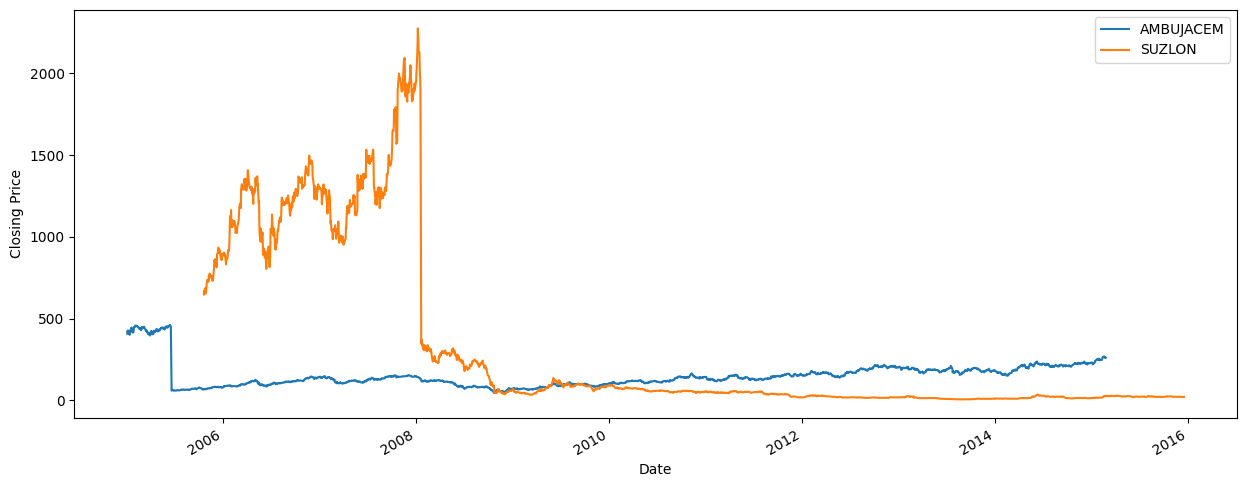

In [26]:
df_ambuja.sort_index(inplace=True)
df_suzlon.sort_index(inplace=True)

fig, ax = plt.subplots(figsize=(15, 6))
df_ambuja["close"].plot(ax=ax, label="AMBUJACEM")
df_suzlon["close"].plot(ax=ax, label="SUZLON")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price")
ax.legend()
plt.show()

**Solution 8.2.6.2**:

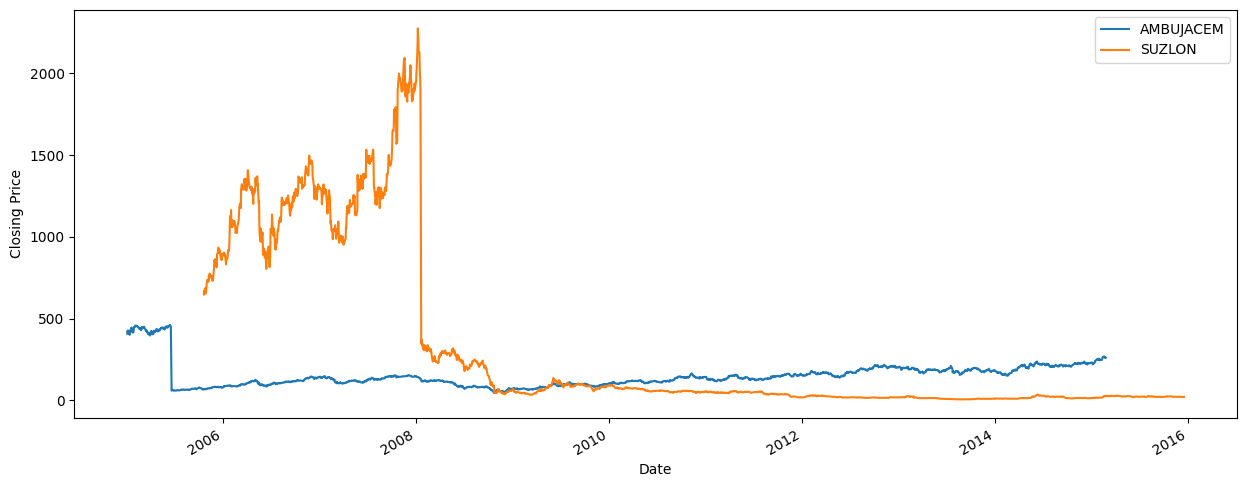

In [25]:
# Sort ascending by date
df_ambuja.sort_index(inplace=True)
df_suzlon.sort_index(inplace=True)

fig, ax = plt.subplots(figsize=(15, 6))
df_ambuja["close"].plot(ax=ax, label="AMBUJACEM")
df_suzlon["close"].plot(ax=ax, label="SUZLON")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price")
ax.legend()
plt.show()

> 📊 Reading the price chart
>
> A shared price axis makes the **scale gap** obvious: the two stocks live
> at very different price levels, so their lines barely interact. This is
> exactly *why* raw prices are a poor basis for comparison — and the cue to
> switch to returns, which are unit-free.

➡️ Same data, but now expressed as returns to expose volatility.

Create a `"return"` column in both DataFrames using `pct_change() * 100`.
Print the first few rows of each to verify.

**Code Task 8.2.6.3**:

In [ ]:
# Compute daily returns
df_ambuja["return"] = ...
df_suzlon["return"] = ...

print("Ambuja returns (head):")
print(df_ambuja[["close", "return"]].head())
print()
print("Suzlon returns (head):")
print(df_suzlon[["close", "return"]].head())

**Solution 8.2.6.3**:

In [30]:
# Compute daily returns
df_ambuja["return"] = df_ambuja["close"].pct_change() * 100
df_suzlon["return"] = df_suzlon["close"].pct_change() * 100

print("Ambuja returns (head):")
print(df_ambuja[["close", "return"]].head())
print()
print("Suzlon returns (head):")
print(df_suzlon[["close", "return"]].head())

Ambuja returns (head):
               close    return
date                          
2005-01-03  407.6001       NaN
2005-01-04  425.8501  4.477428
2005-01-05  425.9501  0.023482
2005-01-06  416.0501 -2.324216
2005-01-07  426.3001  2.463646

Suzlon returns (head):
               close    return
date                          
2005-10-20  647.4003       NaN
2005-10-21  673.1503  3.977446
2005-10-24  653.3503 -2.941394
2005-10-25  659.0003  0.864773
2005-10-26  687.9003  4.385430


As expected, the **first return in each series is `NaN`** (no prior price),
and the values are small percentages — the per-day moves that volatility
modelling will feed on. Now plot them on a shared axis to compare spreads
directly.

**Code 8.2.6.4**:

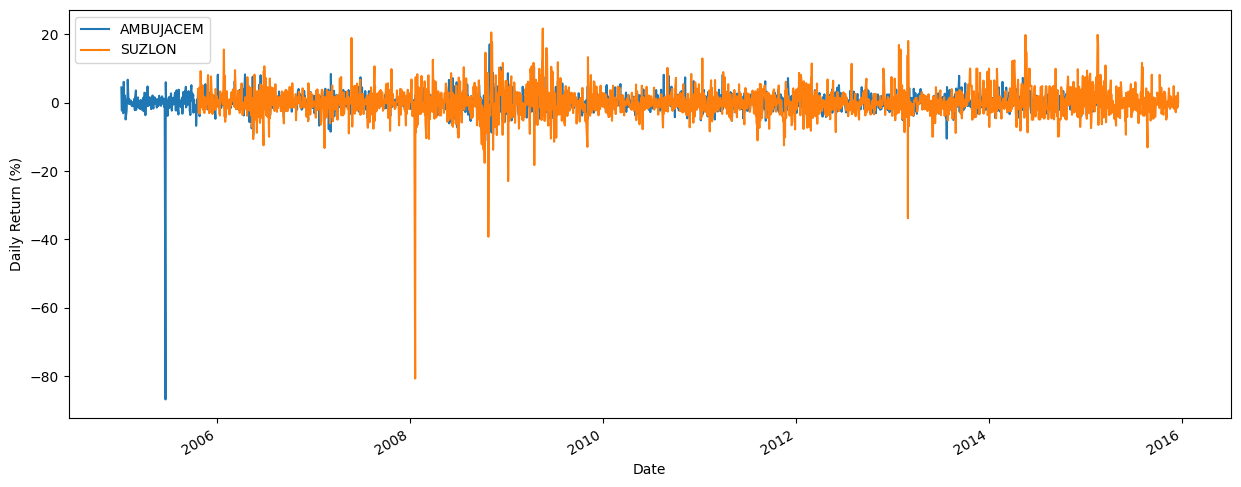

In [29]:
fig, ax = plt.subplots(figsize=(15, 6))
df_ambuja["return"].plot(ax=ax, label="AMBUJACEM")
df_suzlon["return"].plot(ax=ax, label="SUZLON")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")
ax.legend()
plt.show()

**Solution 8.2.6.4**:

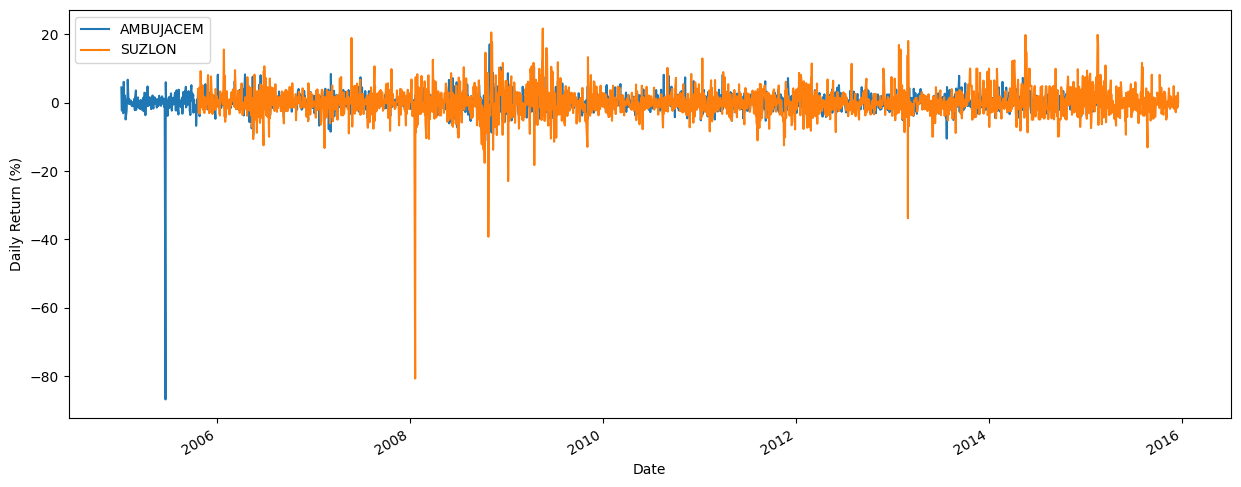

In [31]:
fig, ax = plt.subplots(figsize=(15, 6))
df_ambuja["return"].plot(ax=ax, label="AMBUJACEM")
df_suzlon["return"].plot(ax=ax, label="SUZLON")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")
ax.legend()
plt.show()

> 📊 Reading the return chart
>
> On a common scale the **width of the bands** tells the story: the stock
> with the wider swings is the more volatile one. You should also see the
> Lesson 1 stylized fact reappear — turbulent stretches and calm stretches
> arrive in **runs** (volatility clustering), foreshadowing the GARCH
> models of Lesson 3.

### Checkpoint

> 🧪 The final gate confirms the feature engineering: both frames now carry
> a `"return"` column, the column count grew from 5 to 6, and the first
> return is `NaN` (the expected edge case from `pct_change`).

In [32]:
# --- Returns checkpoint ---
assert "return" in df_ambuja.columns, (
    "df_ambuja is missing the 'return' column"
)
assert "return" in df_suzlon.columns, (
    "df_suzlon is missing the 'return' column"
)
assert df_ambuja.shape[1] == 6, (
    f"df_ambuja should have 6 columns (5 + return), "
    f"got {df_ambuja.shape[1]}"
)
assert df_suzlon.shape[1] == 6, (
    f"df_suzlon should have 6 columns (5 + return), "
    f"got {df_suzlon.shape[1]}"
)
# First return should be NaN (no previous price)
assert pd.isna(df_ambuja["return"].iloc[0]), (
    "First return value should be NaN"
)
print(
    "Checkpoint passed: return columns computed correctly."
)

Checkpoint passed: return columns computed correctly.


> ✅ A passing message means both return series are correctly computed and
> ready for modelling.

# Wrap-up

In this lesson you:

-   **Built** an `AlphaVantageAPI` class that fetches daily stock data and
    returns a clean DataFrame.
-   **Applied test-driven development**, writing `assert` statements to
    validate the type, shape, columns, and dtypes of every output *before*
    trusting it.
-   **Created** a `SQLRepository` class that inserts DataFrames into a
    SQLite database and reads them back with an optional row limit.
-   **Exercised** the full extract → store → retrieve pipeline for two
    stocks.
-   **Computed** daily percentage returns and compared the volatility of
    two stocks visually.

> 🧠 The idea to carry forward: a data layer you can *test* is a data layer
> you can *trust*. By specifying each class's contract as assertions, you
> turned an exploratory script into a dependable foundation — and the
> `AlphaVantageAPI` + `SQLRepository` pair (living in `data.py`) is exactly
> what Lessons 3 and 4 will import.

➡️ **Next**, you will feed these percentage returns into **GARCH models**
to capture and forecast the time-varying volatility you just visualised —
the modelling heart of the project.